In [2]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import numpy as np

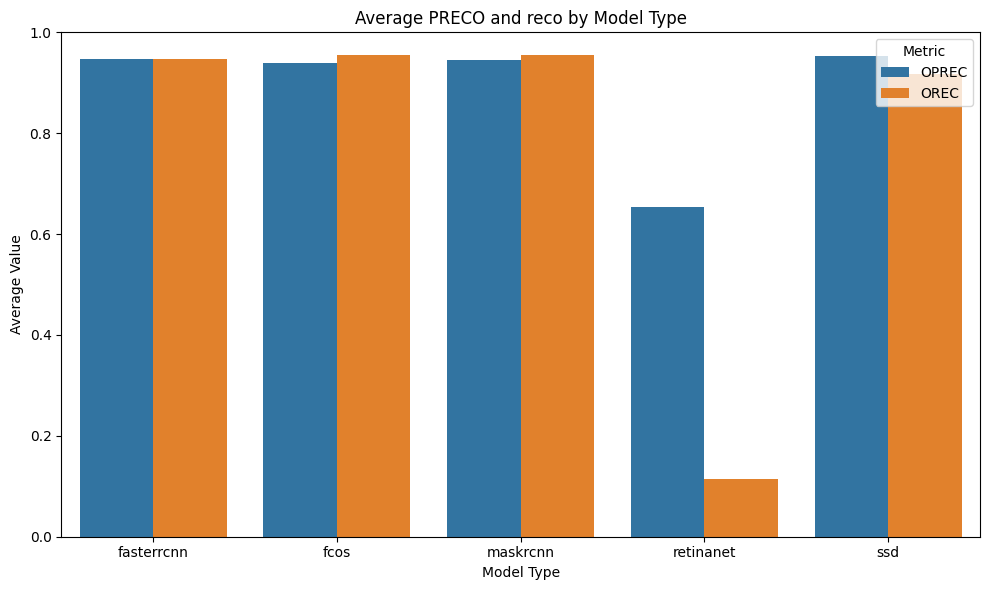

In [3]:
fileName = "./exp2DJAR.csv"

df = pd.read_csv(fileName)

# Step 4: Group by modelType and compute mean of PRECO and reco
avg_metrics = df.groupby('model')[['OPREC', 'OREC']].mean().reset_index()

# Step 5: Melt the DataFrame for plotting
df_melted = avg_metrics.melt(id_vars='model', value_vars=['OPREC', 'OREC'],
                             var_name='Metric', value_name='Average Value')

# Step 6: Plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='model', y='Average Value', hue='Metric', data=df_melted)
plt.title('Average PRECO and reco by Model Type')
plt.ylabel('Average Value')
plt.xlabel('Model Type')
plt.ylim(0, 1)  # since both metrics are between 0 and 1
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig("bestPerModel.png", dpi=300, bbox_inches='tight')
plt.show()


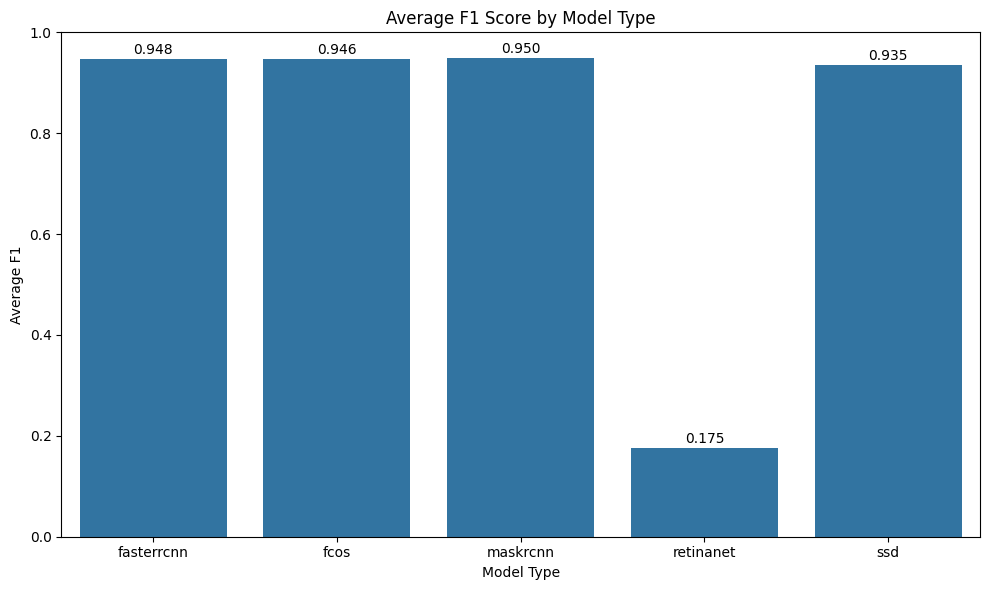

In [5]:
# Compute F1 score
df['F1'] = (2 * df['OPREC'] * df['OREC'] / (df['OPREC'] + df['OREC'])).fillna(0)

# Compute average F1 per model
avg_f1 = df.groupby('model')['F1'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='model', y='F1', data=avg_f1)

# Add F1 value labels
for i, row in avg_f1.iterrows():
    ax.text(
        i,
        row['F1'] + 0.01,
        f"{row['F1']:.3f}",   # 3 decimal places
        ha='center',
        fontsize=10
    )

plt.title('Average F1 Score by Model Type')
plt.ylabel('Average F1')
plt.xlabel('Model Type')
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("f1PerModel.png", dpi=300, bbox_inches='tight')
plt.show()

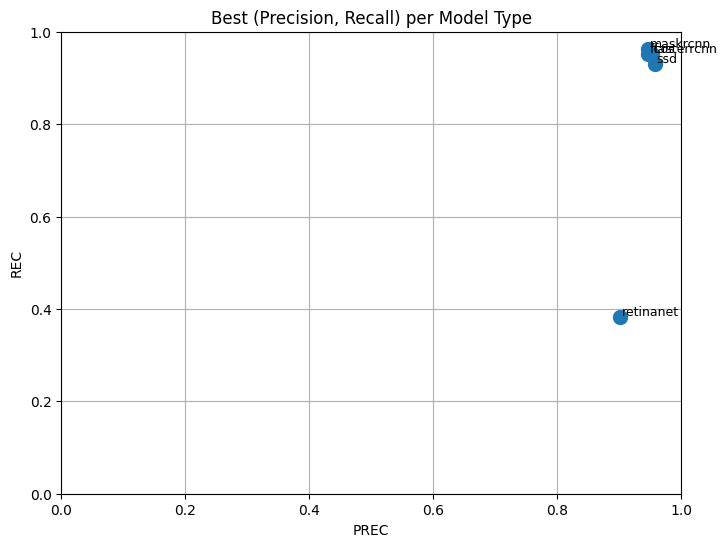

In [16]:
# new functions
import pandas as pd
import matplotlib.pyplot as plt

# === 1) Load your CSV ===
fileName = "./exp2DJAR.csv"
df = pd.read_csv(fileName)

# === 2) Compute the average of PRECO and reco ===
df['avg'] = df[['OPREC', 'OREC']].mean(axis=1)

# === 3) Pick the row with the highest avg per modelType ===
best_per_model = df.loc[df.groupby('model')['avg'].idxmax()]

# === 4) Plot ===
plt.figure(figsize=(8, 6))
plt.scatter(best_per_model['OPREC'], best_per_model['OREC'], s=100)

# Label each point
for _, row in best_per_model.iterrows():
    plt.text(row['OPREC'] + 0.003, row['OREC'] + 0.003, row['model'], fontsize=9)

plt.title("Best (Precision, Recall) per Model Type")
plt.xlabel("PREC")
plt.ylabel("REC")
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.savefig("PRECORECOGEN.jpg")
plt.show()
